In [3]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 604.5 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 106.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, learning_curve

import mlflow
import mlflow.sklearn

import dagshub

dagshub.init(repo_owner='ejoba22', repo_name='walmart-sales-forecasting', mlflow=True)

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=efbf4ee0-e102-49c3-8546-e16cec136211&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=2b870c15205ab30e1eb82a4c9d94445758158246ed76fa7850391c24da06b27b




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/walmart-sales-forecasting"

Repository ejoba22/walmart-sales-forecasting initialized!

## 1. Data Cleaning

In [5]:
BASE = '/kaggle/input/datasets/elenejobava/walmart-feature-engineering/results/'

train_clean = pd.read_parquet(BASE + 'train_clean.parquet')
test_clean  = pd.read_parquet(BASE + 'test_clean.parquet')

with mlflow.start_run(run_name="XGBoost_Cleaning"):
    n_null_train = train_clean.isnull().sum().sum()
    n_null_test  = test_clean.isnull().sum().sum()
    n_negative   = (train_clean['Weekly_Sales'] < 0).sum()

    mlflow.log_param("train_rows", len(train_clean))
    mlflow.log_param("test_rows", len(test_clean))
    mlflow.log_param("negative_sales_kept", True)
    mlflow.log_metric("null_cells_train", int(n_null_train))
    mlflow.log_metric("null_cells_test", int(n_null_test))
    mlflow.log_metric("negative_sales_rows", int(n_negative))

    print(f"train_clean: {train_clean.shape}, test_clean: {test_clean.shape}")
    print(f"Negative sales rows kept as legitimate returns: {n_negative}")
    print(f"Remaining null cells — train: {n_null_train}, test: {n_null_test}")

train_clean: (421570, 16), test_clean: (115064, 15)
Negative sales rows kept as legitimate returns: 1285
Remaining null cells — train: 0, test: 0
🏃 View run XGBoost_Cleaning at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/1ca718e3c27848bd82dbff607d83380f
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0


## 2. Feature Engineering as a Pipeline Step

In [15]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

HOLIDAYS = {
    'SuperBowl':    pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
    'LaborDay':     pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
    'Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
    'Christmas':    pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
}

NAME_MAP = {'SuperBowl': 'super_bowl', 'LaborDay': 'labor_day',
            'Thanksgiving': 'thanksgiving', 'Christmas': 'christmas'}

LAGS = [1, 2, 3, 4, 5, 6, 12, 26, 52]
WINDOWS = [4, 8, 12, 26, 52]


class WalmartFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    fit(): called ONLY on raw merged training data. Stores all train-derived stats
           + the full train history (needed for lag/rolling on rows that come after it).

    transform(): accepts any raw merged dataframe (with or without Weekly_Sales) and
                 returns the final numeric feature matrix.
    """

    def fit(self, X, y=None):
        df = X.copy()
        if 'Weekly_Sales' not in df.columns and y is not None:
            df['Weekly_Sales'] = np.asarray(y)
        df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

        self.train_history_ = df[['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']].copy()

        self.dept_avg_ = df.groupby('Dept')['Weekly_Sales'].mean()
        self.store_dept_avg_ = df.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
        self.store_avg_ = df.groupby('Store')['Weekly_Sales'].mean()

        holiday_sens = (
            df.groupby('Dept')
            .apply(lambda g: g.loc[g['IsHoliday'], 'Weekly_Sales'].mean() /
                              g.loc[~g['IsHoliday'], 'Weekly_Sales'].mean()
                              if (~g['IsHoliday']).any() and g.loc[~g['IsHoliday'], 'Weekly_Sales'].mean() else np.nan,
                   include_groups=False)
        )
        self.dept_holiday_sensitivity_ = holiday_sens

        cv = (
            df.groupby(['Store', 'Dept'])['Weekly_Sales']
            .apply(lambda x: x.std() / x.mean() if x.mean() else 0, include_groups=False)
        )
        self.store_dept_cv_ = cv

        dept_rank = (
            df.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
            .groupby(level='Store').rank(ascending=False)
        )
        self.dept_rank_in_store_ = dept_rank
        self.dept_avg_lt_1000_ = (self.dept_avg_ < 1000)

        df_cal = self._add_calendar(df)
        self.store_dept_week_avg_ = df_cal.groupby(['Store', 'Dept', 'Week'])['Weekly_Sales'].mean()
        return self

    def _add_calendar(self, df):
        df = df.copy()
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
        df['DayOfYear'] = df['Date'].dt.dayofyear
        df['Quarter'] = df['Date'].dt.quarter
        df['Year_norm'] = df['Year'] - 2010
        df['Week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
        df['Week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)
        df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
        dates_arr = df['Date'].values.astype('datetime64[D]')
        for name, dates in HOLIDAYS.items():
            holiday_arr = dates.values.astype('datetime64[D]')
            diffs_days = (dates_arr[:, None] - holiday_arr[None, :]).astype('timedelta64[D]').astype(float)
            diffs_weeks = diffs_days / 7
            idx = np.argmin(np.abs(diffs_weeks), axis=1)
            nearest = diffs_weeks[np.arange(len(dates_arr)), idx]
    
            df[f'weeks_to_{name}'] = nearest
            df[f'near_{name}'] = (np.abs(nearest) <= 2).astype(int)
            df[f'before_{name}'] = (nearest < 0).astype(int)
            df[f'is_{NAME_MAP[name]}'] = df['Date'].isin(dates).astype(int)
        return df

    def transform(self, X):
        df = X.copy()
        has_target = 'Weekly_Sales' in df.columns
        if not has_target:
            df['Weekly_Sales'] = np.nan

        df['any_markdown'] = (df[MARKDOWN_COLS].fillna(0) > 0).any(axis=1).astype(int)
        df['Type_enc'] = df['Type'].map({'A': 2, 'B': 1, 'C': 0})
        df['Size_log'] = np.log1p(df['Size'])

        hist = self.train_history_[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
        hist['_is_new'] = False
        new = df[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
        new['_is_new'] = True
        combined = pd.concat([hist, new], ignore_index=True)
        combined = combined.sort_values(['Store', 'Dept', 'Date'], kind='mergesort')
        combined = combined.drop_duplicates(subset=['Store', 'Dept', 'Date'], keep='last')

        for lag in LAGS:
            combined[f'lag_{lag}'] = combined.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)
        for w in WINDOWS:
            grp = combined.groupby(['Store', 'Dept'])['Weekly_Sales']
            combined[f'rolling_mean_{w}'] = grp.shift(1).transform(lambda x: x.rolling(w, min_periods=1).mean())
            combined[f'rolling_std_{w}'] = grp.shift(1).transform(lambda x: x.rolling(w, min_periods=1).std())
            combined[f'rolling_max_{w}'] = grp.shift(1).transform(lambda x: x.rolling(w, min_periods=1).max())
        combined['expanding_mean'] = combined.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).transform(
            lambda x: x.expanding().mean())

        lag_cols = [c for c in combined.columns if c.startswith(('lag_', 'rolling_', 'expanding_'))]
        combined_new = combined[combined['_is_new']][['Store', 'Dept', 'Date'] + lag_cols]

        df = df.merge(combined_new, on=['Store', 'Dept', 'Date'], how='left')
        df = self._add_calendar(df)

        df = df.join(self.dept_avg_.rename('dept_avg_sales'), on='Dept')
        df = df.join(self.store_dept_avg_.rename('store_dept_avg_sales'), on=['Store', 'Dept'])
        df = df.join(self.store_dept_week_avg_.rename('store_dept_week_avg'), on=['Store', 'Dept', 'Week'])
        df = df.join(self.dept_holiday_sensitivity_.rename('dept_holiday_sensitivity'), on='Dept')
        df = df.join(self.store_dept_cv_.rename('store_dept_cv'), on=['Store', 'Dept'])
        df = df.join(self.store_avg_.rename('store_avg_sales'), on='Store')
        df = df.join(self.dept_rank_in_store_.rename('dept_rank_in_store'), on=['Store', 'Dept'])

        df['store_dept_avg_sales'] = df['store_dept_avg_sales'].fillna(df['dept_avg_sales'])
        df['store_dept_week_avg'] = df['store_dept_week_avg'].fillna(df['store_dept_avg_sales'])
        df['store_dept_cv'] = df['store_dept_cv'].fillna(0)
        df['dept_rank_in_store'] = df['dept_rank_in_store'].fillna(self.dept_rank_in_store_.median())

        df['IsHoliday'] = df['IsHoliday'].astype(int)
        df['total_markdown'] = df[MARKDOWN_COLS].fillna(0).sum(axis=1)
        df['active_markdown_count'] = (df[MARKDOWN_COLS].fillna(0) > 0).sum(axis=1)
        df['is_sparse_dept'] = df['Dept'].map(self.dept_avg_lt_1000_).fillna(False).astype(int)
        df['markdown_x_holiday'] = df['total_markdown'] * df['IsHoliday']

        self.feature_cols_ = [c for c in df.columns
                               if c not in ['Weekly_Sales', 'Date', 'Store_Dept', 'Type']]
        out = df[self.feature_cols_].copy()
        return out

## 3. Feature Selection 

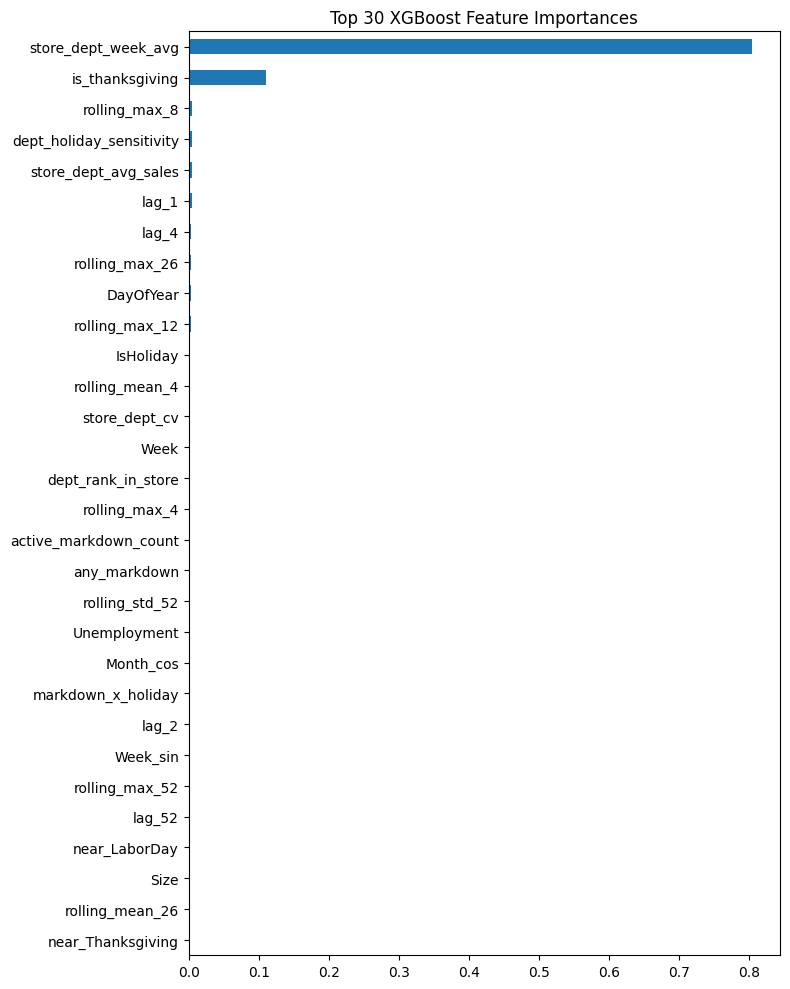

🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/d467002f30454e26a472d55dd48ba98f
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
store_dept_week_avg         0.803717
is_thanksgiving             0.110093
rolling_max_8               0.005228
dept_holiday_sensitivity    0.004869
store_dept_avg_sales        0.004510
lag_1                       0.004040
lag_4                       0.003422
rolling_max_26              0.003377
DayOfYear                   0.002853
rolling_max_12              0.002766
IsHoliday                   0.002459
rolling_mean_4              0.002411
store_dept_cv               0.002241
Week                        0.002222
dept_rank_in_store          0.002141
rolling_max_4               0.002130
active_markdown_count       0.001631
any_markdown                0.001444
rolling_std_52              0.001434
Unemployment                0.001407
dtype

In [16]:
fe = WalmartFeatureEngineer()
fe.fit(train_clean)
X_full = fe.transform(train_clean)
y_full = train_clean.sort_values(['Store', 'Dept', 'Date'])['Weekly_Sales'].values
dates_full = train_clean.sort_values(['Store', 'Dept', 'Date'])['Date'].values

numeric_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
X_full = X_full[numeric_cols]

lag_dependent_cols = [c for c in numeric_cols if c.startswith(('lag_', 'rolling_', 'expanding_'))]

quick_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
quick_model.fit(X_full.fillna(-999), y_full)
importances = pd.Series(quick_model.feature_importances_, index=numeric_cols).sort_values(ascending=False)

with mlflow.start_run(run_name="XGBoost_Feature_Selection"):
    mlflow.log_param("n_features_total", len(numeric_cols))
    mlflow.log_param("n_lag_dependent_features", len(lag_dependent_cols))
    mlflow.log_text(str(lag_dependent_cols), "lag_dependent_features.txt")

    fig, ax = plt.subplots(figsize=(8, 10))
    importances.head(30).sort_values().plot.barh(ax=ax)
    ax.set_title("Top 30 XGBoost Feature Importances")
    plt.tight_layout()
    mlflow.log_figure(fig, "top30_importance.png")
    plt.show()

print(importances.head(20))

In [8]:
[c for c in X_full.columns if c.startswith('is_')]

['is_super_bowl',
 'is_labor_day',
 'is_thanksgiving',
 'is_christmas',
 'is_sparse_dept']

## 4. Custom Metric WMAE

In [9]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

## 5. Time-Based Cross-Validation

In [11]:
train_sorted_raw = train_clean.sort_values('Date').reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
fold_scores = []

with mlflow.start_run(run_name="XGBoost_CV"):
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(train_sorted_raw)):
        train_slice = train_sorted_raw.iloc[tr_idx]
        val_slice = train_sorted_raw.iloc[val_idx]

        pipe = Pipeline([
            ('fe', WalmartFeatureEngineer()),
            ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
            ('xgb', xgb.XGBRegressor(
                n_estimators=400, max_depth=7, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE))
        ])

        y_tr = train_slice['Weekly_Sales'].values
        y_val = val_slice['Weekly_Sales'].values
        hol_val = val_slice['IsHoliday'].values

        pipe.fit(train_slice, y_tr)
        preds = pipe.predict(val_slice)
        score = wmae(y_val, preds, hol_val)
        fold_scores.append(score)

        with mlflow.start_run(run_name=f"XGBoost_CV_fold{fold}", nested=True):
            mlflow.log_param("fold", fold)
            mlflow.log_param("train_rows", len(tr_idx))
            mlflow.log_param("val_rows", len(val_idx))
            mlflow.log_param("train_date_range",
                              f"{train_slice['Date'].min().date()} to {train_slice['Date'].max().date()}")
            mlflow.log_param("val_date_range",
                              f"{val_slice['Date'].min().date()} to {val_slice['Date'].max().date()}")
            mlflow.log_metric("fold_wmae", score)

        print(f"Fold {fold}: train={len(tr_idx)} val={len(val_idx)} WMAE={score:.2f}  "
              f"(train {train_slice['Date'].min().date()}–{train_slice['Date'].max().date()}, "
              f"val {val_slice['Date'].min().date()}–{val_slice['Date'].max().date()})")

    mlflow.log_metric("cv_wmae_mean", float(np.mean(fold_scores)))
    mlflow.log_metric("cv_wmae_std", float(np.std(fold_scores)))

print(f"\nMean CV WMAE: {np.mean(fold_scores):.2f} +/- {np.std(fold_scores):.2f}")

🏃 View run XGBoost_CV_fold0 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/0736f6e3217547588958d83cd91dff89
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Fold 0: train=70265 val=70261 WMAE=4079.28  (train 2010-02-05–2010-07-16, val 2010-07-16–2010-12-31)
🏃 View run XGBoost_CV_fold1 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/de5f3e3eef6a4fdb9dbb59ba6e19d143
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Fold 1: train=140526 val=70261 WMAE=2228.37  (train 2010-02-05–2010-12-31, val 2010-12-31–2011-06-17)
🏃 View run XGBoost_CV_fold2 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/963881c6551f4c73a49affa9846bdd88
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Fold 2: train=210787 val=70261 WMAE=1823.18  (train 2010-02

## 6. Overfitting / Underfitting Diagnostics 

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:24:43] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


🏃 View run XGBoost_Overfit_Underfit_underfit at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/35c9d29a487144b19119a5fce073ced7
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
underfit   train_WMAE=  1742.8  val_WMAE=  1862.0  gap=   119.2
🏃 View run XGBoost_Overfit_Underfit_overfit at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/dd4da7e5565643269c0e9d4fb9a1e9e8
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
overfit    train_WMAE=     0.0  val_WMAE=  1886.2  gap=  1886.2
🏃 View run XGBoost_Overfit_Underfit_tuned at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/fcfc669300e5435295676adbf97d3b3f
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
tuned      train_WMAE=   747.7  val_WMAE=  1534.8  gap=   787.1


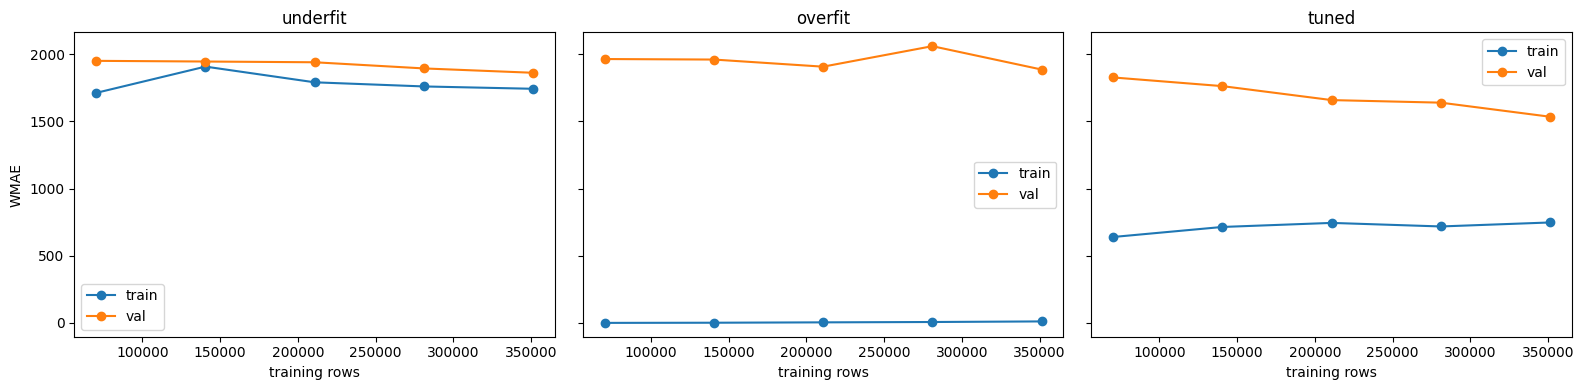

🏃 View run XGBoost_Overfit_Underfit at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/7f2ff35fcedb446ca34495051a5a5362
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0

Summary:
underfit   train=1742.8  val=1862.0  gap=119.2
overfit    train=0.0  val=1886.2  gap=1886.2
tuned      train=747.7  val=1534.8  gap=787.1


In [13]:
train_idx, val_idx = list(tscv.split(train_sorted_raw))[-1]
train_slice = train_sorted_raw.iloc[train_idx]
val_slice = train_sorted_raw.iloc[val_idx]

diag_fe = WalmartFeatureEngineer()
diag_fe.fit(train_slice)
X_tr = diag_fe.transform(train_slice)
X_val = diag_fe.transform(val_slice)

numeric_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
X_tr = X_tr[numeric_cols]
X_val = X_val[numeric_cols]

y_tr = train_slice['Weekly_Sales'].values
y_val = val_slice['Weekly_Sales'].values
hol_tr = train_slice['IsHoliday'].values
hol_val = val_slice['IsHoliday'].values

GPU_PARAMS = dict(tree_method='hist', device='cuda')

configs = {
    "underfit": dict(n_estimators=30, max_depth=2, learning_rate=0.3,
                      reg_lambda=50, reg_alpha=10, subsample=0.5, colsample_bytree=0.5),
    "overfit": dict(n_estimators=1500, max_depth=15, learning_rate=0.3,
                     reg_lambda=0, reg_alpha=0, subsample=1.0, colsample_bytree=1.0),
    "tuned": dict(n_estimators=400, max_depth=7, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8),
}

results = {}
with mlflow.start_run(run_name="XGBoost_Overfit_Underfit"):
    for name, params in configs.items():
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
            ('xgb', xgb.XGBRegressor(random_state=RANDOM_STATE, **params, **GPU_PARAMS))
        ])
        pipe.fit(X_tr, y_tr)
        train_wmae = wmae(y_tr, pipe.predict(X_tr), hol_tr)
        val_wmae = wmae(y_val, pipe.predict(X_val), hol_val)
        gap = val_wmae - train_wmae
        results[name] = dict(train_wmae=train_wmae, val_wmae=val_wmae, gap=gap)

        with mlflow.start_run(run_name=f"XGBoost_Overfit_Underfit_{name}", nested=True):
            mlflow.log_params(params)
            mlflow.log_metric("train_wmae", train_wmae)
            mlflow.log_metric("val_wmae", val_wmae)
            mlflow.log_metric("train_val_gap", gap)

        print(f"{name:10s} train_WMAE={train_wmae:8.1f}  val_WMAE={val_wmae:8.1f}  gap={gap:8.1f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    train_sizes = np.linspace(0.2, 1.0, 5)

    for ax, (name, params) in zip(axes, configs.items()):
        lc_params = dict(params)
        if name == "overfit":
            lc_params['n_estimators'] = 300

        train_wmaes, val_wmaes = [], []
        for frac in train_sizes:
            n = int(frac * len(X_tr))
            pipe = Pipeline([
                ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
                ('xgb', xgb.XGBRegressor(random_state=RANDOM_STATE, **lc_params, **GPU_PARAMS))
            ])
            pipe.fit(X_tr.iloc[:n], y_tr[:n])
            train_wmaes.append(wmae(y_tr[:n], pipe.predict(X_tr.iloc[:n]), hol_tr[:n]))
            val_wmaes.append(wmae(y_val, pipe.predict(X_val), hol_val))

        ax.plot(train_sizes * len(X_tr), train_wmaes, marker='o', label='train')
        ax.plot(train_sizes * len(X_tr), val_wmaes, marker='o', label='val')
        ax.set_title(name)
        ax.set_xlabel('training rows')
        ax.legend()
    axes[0].set_ylabel('WMAE')
    plt.tight_layout()
    mlflow.log_figure(fig, "learning_curves.png")
    plt.show()

print("\nSummary:")
for name, r in results.items():
    print(f"{name:10s} train={r['train_wmae']:.1f}  val={r['val_wmae']:.1f}  gap={r['gap']:.1f}")

In [17]:
X_full[['weeks_to_SuperBowl','weeks_to_LaborDay','weeks_to_Thanksgiving','weeks_to_Christmas']].describe()

,weeks_to_SuperBowl,weeks_to_LaborDay,weeks_to_Thanksgiving,weeks_to_Christmas
count,421570.000000,421570.000000,421570.000000,421570.000000
mean,1.238646,-2.881125,-5.856816,-7.229509
std,15.385920,15.164782,17.552256,18.952018
min,-25.000000,-31.000000,-42.000000,-47.000000
25%,-13.000000,-16.000000,-19.000000,-21.000000
50%,3.000000,-4.000000,-7.000000,-9.000000
75%,15.000000,9.000000,9.000000,9.000000
max,26.000000,26.000000,26.000000,26.000000


## 7. Hyperparameter Tuning

In [18]:
from sklearn.metrics import make_scorer

def wmae_scorer(estimator, X, y):
    preds = estimator.predict(X)
    holiday = X['IsHoliday'].values
    return -wmae(y, preds, holiday)  

GPU_PARAMS = dict(tree_method='hist', device='cuda')

param_dist = {
    'xgb__n_estimators': [200, 400, 600, 800],
    'xgb__max_depth': [4, 5, 6, 7, 8, 9],
    'xgb__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'xgb__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'xgb__reg_lambda': [0.1, 1, 5, 10],
    'xgb__reg_alpha': [0, 0.1, 1, 5],
}

base_pipe = Pipeline([
    ('fe', WalmartFeatureEngineer()),
    ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('xgb', xgb.XGBRegressor(random_state=RANDOM_STATE, **GPU_PARAMS))
])

search = RandomizedSearchCV(
    base_pipe, param_distributions=param_dist, n_iter=30,
    scoring=wmae_scorer, cv=TimeSeriesSplit(n_splits=4),
    random_state=RANDOM_STATE, n_jobs=1, verbose=2)

with mlflow.start_run(run_name="XGBoost_HPO"):
    search.fit(train_sorted_raw, train_sorted_raw['Weekly_Sales'].values)

    mlflow.log_params(search.best_params_)
    mlflow.log_metric("best_cv_wmae", -search.best_score_)

    for i, (params, score) in enumerate(zip(search.cv_results_['params'],
                                             search.cv_results_['mean_test_score'])):
        with mlflow.start_run(run_name=f"XGBoost_HPO_trial_{i}", nested=True):
            mlflow.log_params(params)
            mlflow.log_metric("cv_wmae", -score)

print("Best params:", search.best_params_)
print("Best CV WMAE:", -search.best_score_)

Fitting 4 folds for each of 30 candidates, totalling 120 fits
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.08, xgb__max_depth=5, xgb__n_estimators=400, xgb__reg_alpha=0.1, xgb__reg_lambda=10, xgb__subsample=0.6; total time=   4.1s
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.08, xgb__max_depth=5, xgb__n_estimators=400, xgb__reg_alpha=0.1, xgb__reg_lambda=10, xgb__subsample=0.6; total time=   6.4s
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.08, xgb__max_depth=5, xgb__n_estimators=400, xgb__reg_alpha=0.1, xgb__reg_lambda=10, xgb__subsample=0.6; total time=   8.9s
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.08, xgb__max_depth=5, xgb__n_estimators=400, xgb__reg_alpha=0.1, xgb__reg_lambda=10, xgb__subsample=0.6; total time=  11.4s
[CV] END xgb__colsample_bytree=0.6, xgb__learning_rate=0.01, xgb__max_depth=6, xgb__n_estimators=600, xgb__reg_alpha=5, xgb__reg_lambda=0.1, xgb__subsample=0.6; total time=   5.2s
[CV] END xgb__colsample_bytree=0.6

## 7 Final Holdout Check

In [19]:
cutoff_date = train_sorted_raw['Date'].max() - pd.Timedelta(weeks=12)
holdout_train = train_sorted_raw[train_sorted_raw['Date'] <= cutoff_date]
holdout_val   = train_sorted_raw[train_sorted_raw['Date'] > cutoff_date]

best_params = {k.replace('xgb__', ''): v for k, v in search.best_params_.items()}

holdout_pipe = Pipeline([
    ('fe', WalmartFeatureEngineer()),
    ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('xgb', xgb.XGBRegressor(random_state=RANDOM_STATE, **best_params, **GPU_PARAMS))
])
holdout_pipe.fit(holdout_train, holdout_train['Weekly_Sales'].values)
holdout_preds = holdout_pipe.predict(holdout_val)
holdout_wmae = wmae(holdout_val['Weekly_Sales'].values, holdout_preds, holdout_val['IsHoliday'].values)

with mlflow.start_run(run_name="XGBoost_Final_Holdout_Check"):
    mlflow.log_params(best_params)
    mlflow.log_metric("holdout_wmae", holdout_wmae)
    mlflow.log_metric("hpo_cv_wmae_reference", -search.best_score_)

print(f"HPO CV WMAE (selection score, mild optimism expected): {-search.best_score_:.2f}")
print(f"Final holdout WMAE (unbiased, untouched by HPO):        {holdout_wmae:.2f}")

🏃 View run XGBoost_Final_Holdout_Check at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/8d9a67c9790347429f84bb03dff103a5
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
HPO CV WMAE (selection score, mild optimism expected): 2148.59
Final holdout WMAE (unbiased, untouched by HPO):        1404.79


## 8. Final Model

In [21]:
best_params = {k.replace('xgb__', ''): v for k, v in search.best_params_.items()}

full_pipeline = Pipeline([
    ('fe', WalmartFeatureEngineer()),
    ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('xgb', xgb.XGBRegressor(random_state=RANDOM_STATE, **best_params, **GPU_PARAMS))
])

full_pipeline.fit(train_sorted_raw, train_sorted_raw['Weekly_Sales'].values)

final_train_preds = full_pipeline.predict(train_sorted_raw)
final_train_wmae = wmae(train_sorted_raw['Weekly_Sales'].values, final_train_preds,
                         train_sorted_raw['IsHoliday'].values)

with mlflow.start_run(run_name="XGBoost_Final") as run:
    mlflow.log_params(best_params)
    mlflow.log_metric("final_train_wmae", final_train_wmae)
    mlflow.log_metric("hpo_cv_wmae", -search.best_score_)
    mlflow.log_metric("holdout_wmae", holdout_wmae)

    mlflow.sklearn.log_model(
        sk_model=full_pipeline,
        name="model",
        registered_model_name="walmart_xgboost",
        serialization_format="cloudpickle"
    )
    print(f"Registered model in run {run.info.run_id}")

print(f"Final (full-train) WMAE:  {final_train_wmae:.2f}  (in-sample, expect optimistic)")
print(f"HPO CV WMAE (selection):  {-search.best_score_:.2f}")
print(f"Holdout WMAE (unbiased):  {holdout_wmae:.2f}  (holiday-free window, see caveat)")

2026/07/04 21:07:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'walmart_xgboost'.
2026/07/04 21:07:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: walmart_xgboost, version 1
Created version '1' of model 'walmart_xgboost'.


Registered model in run 2ab6029dba7b421a8696ad8a32200f75
🏃 View run XGBoost_Final at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/2ab6029dba7b421a8696ad8a32200f75
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Final (full-train) WMAE:  1068.37  (in-sample, expect optimistic)
HPO CV WMAE (selection):  2148.59
Holdout WMAE (unbiased):  1404.79  (holiday-free window, see caveat)


In [22]:
test_preds_naive = full_pipeline.predict(test_clean)
print(test_preds_naive[:20])
print(f"Any negative predictions: {(test_preds_naive < 0).sum()}")
print(f"Any NaN predictions: {pd.isna(test_preds_naive).sum()}")

[37381.875 18303.756 17706.014 18582.422 20156.488 27522.629 36951.453
 41359.105 18203.037 14109.071 14763.903 15421.323 15879.463 20330.14
 33778.242 37506.66  17000.258 17784.268 18012.31  18495.973]
Any negative predictions: 0
Any NaN predictions: 0
